In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
  sys.path.insert(0, str(ROOT))

import fiddle as fdl
from src.utils.config import parse_fiddle_config

import random
import torch
from torchvision.io import read_image, ImageReadMode

from src.datasets.fungitastic import FungiTasticDataset, FungiTasticDataModule
from src.models.architectures.encdecnet import EncDecNetBackbone
from src.models.architectures.deeplabv3_mobilenet_v3_large import MobileNetV3
from src.models.segmentation_model import SegmentationModel
from src.datasets.augmentation import build_train_transform, build_eval_transform
import matplotlib.pyplot as plt


In [2]:
CKPT_PATH = "../logs/weighted_augmented_deeplabv3_mobilenet_v3_large_segmenter_20260430_132604/epoch=8-step=7767.ckpt"
CONFIG_PATH = "../src/config/deeplabv3_mobilenet_v3_large_segmenter.py"
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
cfg = parse_fiddle_config(CONFIG_PATH)
built_cfg = fdl.build(cfg)

model = built_cfg.model
checkpoint = torch.load(CKPT_PATH, map_location="cpu")
model.load_state_dict(checkpoint["state_dict"], strict=False)

model = model.to(device)
model.eval()

dataset = FungiTasticDataset(
  "../data/FungiTastic",
  split="train",
  transform=build_train_transform()
)

In [4]:
CLASS_NAMES = {
  0: "background",
  1: "cap",
  2: "stem",
  3: "gills",
  4: "pores",
  5: "ring"
}

PALETTE = torch.tensor([
  [0, 0, 0],
  [220, 60, 60],
  [60, 160, 80],
  [80, 120, 220],
  [230, 180, 60],
  [180, 80, 220]
], dtype=torch.uint8)

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def unnormalize(image):
    image = image.cpu() * IMAGENET_STD + IMAGENET_MEAN
    image = image.clamp(0, 1)
    return image.permute(1, 2, 0)

def colorize_mask(mask):
    mask = mask.cpu().long()
    return PALETTE[mask].numpy()


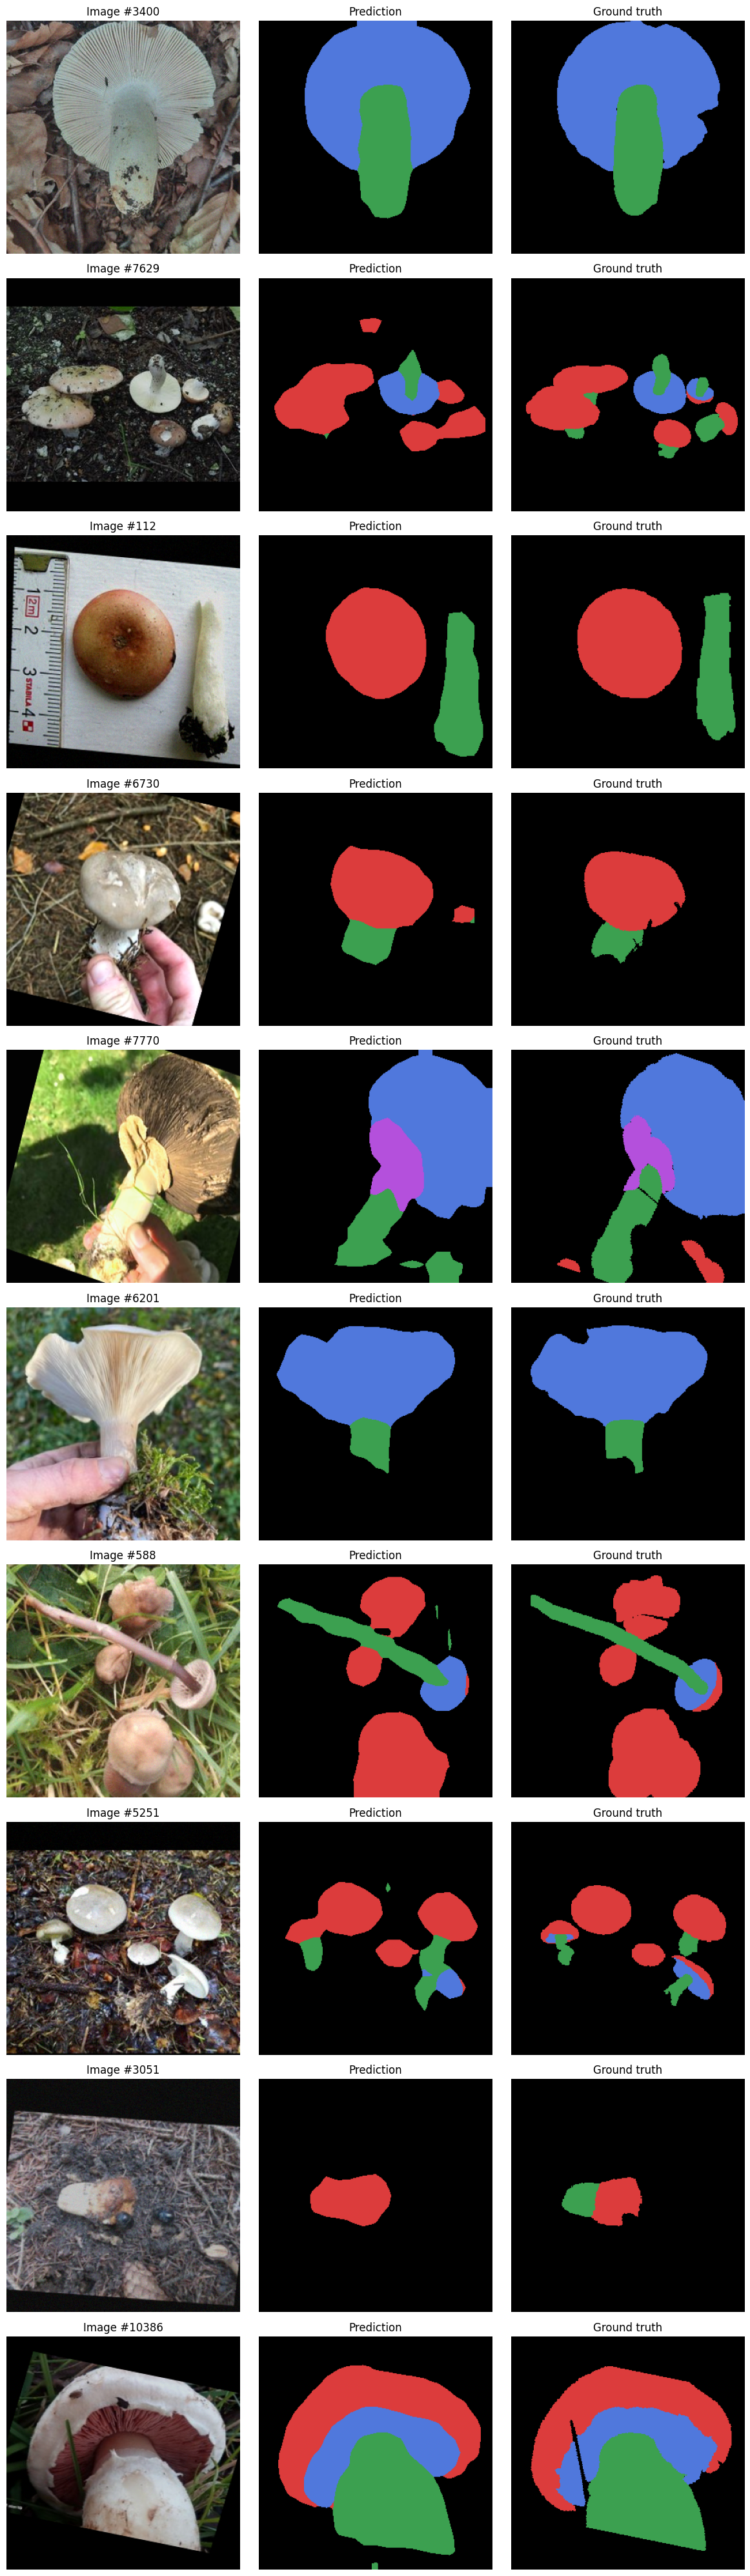

In [ ]:
indices = random.sample(range(len(dataset)), 10)
rows = []

with torch.inference_mode():
  for idx in indices:
    image, gt_mask = dataset[idx]
    logits = model(image.view(1, 3, 300, 300).to(device))
    pred_mask = logits.argmax(dim=1).squeeze(0).cpu()
    rows.append((idx, image.cpu(), pred_mask, gt_mask.cpu()))

fix, axes = plt.subplots(
  nrows=len(rows),
  ncols=3,
  figsize=(12, 4*len(rows))
)

for row_idx, (idx, image, pred_mask, gt_mask) in enumerate(rows):
  axes[row_idx, 0].imshow(unnormalize(image))
  axes[row_idx, 0].set_title(f"Image #{idx}")
  axes[row_idx, 1].imshow(colorize_mask(pred_mask))
  axes[row_idx, 1].set_title("Prediction")
  axes[row_idx, 2].imshow(colorize_mask(gt_mask))
  axes[row_idx, 2].set_title("Ground truth")

  for col in range(3):
    axes[row_idx, col].axis('off')

plt.tight_layout()
plt.savefig('../reports/results.png')
plt.show()